In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 

In [2]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

## Functions

In [3]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [4]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [5]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

### Plotting functions

In [6]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba
# import seaborn as sns
# from scipy.stats import pearsonr

# def plot_WMLD_scatter_matrix(
#     ds,
#     y_var='WMLD',
#     en1=(pd.Timestamp('1982-08-01'), pd.Timestamp('1983-12-31')),  # gray
#     en2=(pd.Timestamp('1997-04-01'), pd.Timestamp('1998-06-30')),  # black
#     var_colors=None,
# ):
#     """
#     Scatter plots of y_var vs other variables from an xarray.Dataset in 2×4 layout.
#     Colors EN 1982–83 points gray and EN 1997–98 points black. Works with monthly time.
#     """

#     # Base colors for non-EN points
#     base_colors = {
#         'WMLD': 'black',
#         'BUI': 'royalblue',
#         'Ekman_pump': 'steelblue',
#         'Ekman_transport': 'steelblue',
#         'CUTI': 'slateblue',
#         'BEUTI': 'orange',
#         'CUI': 'red',
#         'AV': 'dodgerblue'
#     }
#     if var_colors:
#         base_colors.update(var_colors)

#     # To DataFrame keeping coords
#     df = ds.to_dataframe().reset_index()

#     # Detect time
#     has_time = 'time' in df.columns and np.issubdtype(df['time'].dtype, np.datetime64)
#     t = pd.to_datetime(df['time']) if has_time else pd.Series(pd.NaT, index=df.index)

#     # EN masks (monthly)
#     en1_mask = (t >= en1[0]) & (t <= en1[1]) if has_time else np.zeros(len(df), dtype=bool)
#     en2_mask = (t >= en2[0]) & (t <= en2[1]) if has_time else np.zeros(len(df), dtype=bool)

#     # Variables to plot (numeric, excluding y_var and non-data columns)
#     numeric_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
#     vars_to_plot = [c for c in numeric_cols if c != y_var]

#     # Grid
#     n = min(len(vars_to_plot), 8)
#     nrows, ncols = 2, 4
#     fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 7), constrained_layout=True)
#     axs = axs.flatten()

#     def make_point_colors(n_points, base_color, en1_m, en2_m, alpha=0.7):
#         c = np.array([to_rgba(base_color, alpha)] * n_points, dtype=object)
#         c[en1_m] = to_rgba('gray', alpha)   # 1982–1983
#         c[en2_m] = to_rgba('black', alpha)  # 1997–1998
#         return c

#     for i, ax in enumerate(axs):
#         if i >= n:
#             ax.axis('off')
#             continue

#         var = vars_to_plot[i]
#         sub_df = df[[var, y_var]].dropna()
#         if sub_df.empty:
#             ax.set_axis_off()
#             continue

#         # Align masks to NA-dropped subset
#         idx = sub_df.index
#         x = sub_df[var].to_numpy()
#         y = sub_df[y_var].to_numpy()
#         en1_m = en1_mask[idx].to_numpy() if hasattr(en1_mask, 'to_numpy') else en1_mask[idx]
#         en2_m = en2_mask[idx].to_numpy() if hasattr(en2_mask, 'to_numpy') else en2_mask[idx]

#         base_color = base_colors.get(var, 'tab:blue')
#         point_colors = make_point_colors(len(sub_df), base_color, en1_m, en2_m, alpha=0.7)

#         # 1) Plot scatter only (no regression) with custom colors
#         ax.scatter(x, y, c=point_colors, edgecolors='none')

#         # 2) Fit and plot regression line on all points
#         try:
#             sns.regplot(
#                 x=x, y=y, ax=ax, ci=95, scatter=False,
#                 line_kws={'color': base_color, 'lw': 2},
#             )
#         except Exception:
#             pass

#         # Pearson r^2
#         try:
#             r, _ = pearsonr(x, y)
#             ax.text(
#                 0.04, 0.96, f"$r^2$ = {r**2:.2f}",
#                 transform=ax.transAxes, va='top', ha='left', fontsize=11,
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
#             )
#         except Exception:
#             ax.text(0.04, 0.96, "r^2 n/a", transform=ax.transAxes)

#         ax.set_xlabel(var)
#         ax.set_ylabel(y_var)
#         ax.set_title(f'{y_var} vs {var}', fontsize=11)

#     # Legend for EN periods
#     from matplotlib.lines import Line2D
#     legend_elems = [
#         Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', markersize=8, label='EN 1982–1983'),
#         Line2D([0], [0], marker='o', color='none', markerfacecolor='black', markersize=8, label='EN 1997–1998'),
#     ]
#     fig.legend(handles=legend_elems, loc='upper right')

#     return fig, axs

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import seaborn as sns
from scipy.stats import pearsonr

def plot_WMLD_scatter_matrix(
    ds,
    y_var='WMLD',
    en1=(pd.Timestamp('1982-08-01'), pd.Timestamp('1983-12-31')),  # gray
    en2=(pd.Timestamp('1997-04-01'), pd.Timestamp('1998-08-30')),  # black
    var_colors=None,
):
    """
    Scatter plots of y_var vs other variables from an xarray.Dataset in 2×4 layout.
    Colors EN 1982–83 points gray and EN 1997–98 points black.
    Works with monthly (time) or yearly (year) data.
    """

    # Base colors for non-EN points
    base_colors = {
        'WMLD': 'black',
        'BUI': 'royalblue',
        'Ekman_pump': 'steelblue',
        'Ekman_transport': 'steelblue',
        'CUTI': 'slateblue',
        'BEUTI': 'orange',
        'CUI': 'red',
        'AV': 'dodgerblue'
    }
    if var_colors:
        base_colors.update(var_colors)

    # To DataFrame keeping coords
    df = ds.to_dataframe().reset_index()

    # Ensure we have a temporal column to derive EN masks
    has_time = 'time' in df.columns and np.issubdtype(df['time'].dtype, np.datetime64)
    has_year_col = 'year' in df.columns and np.issubdtype(df['year'].dtype, np.integer)

    # Build EN masks depending on granularity
    en1_mask = np.zeros(len(df), dtype=bool)
    en2_mask = np.zeros(len(df), dtype=bool)

    if has_time:
        t = pd.to_datetime(df['time'])
        # Monthly masks
        en1_mask = (t >= en1[0]) & (t <= en1[1])   # 1982-08 .. 1983-12
        en2_mask = (t >= en2[0]) & (t <= en2[1])   # 1997-04 .. 1998-06

        # Also compute a year column for fallback/aggregation cases
        df['_year'] = t.dt.year

    elif has_year_col:
        y = pd.to_numeric(df['year'], errors='coerce')
        # Yearly masks: mark whole years overlapping the EN windows
        en1_years = set(range(en1[0].year, en1[1].year + 1))  # {1982, 1983}
        en2_years = set(range(en2[0].year, en2[1].year + 1))  # {1997, 1998}
        en1_mask = y.isin(en1_years).to_numpy()
        en2_mask = y.isin(en2_years).to_numpy()
        df['_year'] = y

    else:
        # Try to infer a year from any datetime-like column in the index/coords
        maybe_time_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.datetime64)]
        if maybe_time_cols:
            t = pd.to_datetime(df[maybe_time_cols[0]])
            en1_mask = (t >= en1[0]) & (t <= en1[1])
            en2_mask = (t >= en2[0]) & (t <= en2[1])
            df['_year'] = t.dt.year
        else:
            # No temporal info; leave masks false
            df['_year'] = np.nan

    # Variables to plot (numeric, excluding y_var and coordinate/helper columns)
    non_data = {'time', 'year', '_year'}
    numeric_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    vars_to_plot = [c for c in numeric_cols if (c != y_var and c not in non_data)]

    # Grid
    n = min(len(vars_to_plot), 8)
    nrows, ncols = 2, 4
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 7), constrained_layout=True)
    axs = axs.flatten()

    def make_point_colors(n_points, base_color, en1_m, en2_m, alpha=0.7):
        c = np.array([to_rgba(base_color, alpha)] * n_points, dtype=object)
        c[en1_m] = to_rgba('gray', alpha)   # 1982–1983
        c[en2_m] = to_rgba('black', alpha)  # 1997–1998
        return c

    en1_mask_series = pd.Series(en1_mask, index=df.index)
    en2_mask_series = pd.Series(en2_mask, index=df.index)

    for i, ax in enumerate(axs):
        if i >= n:
            ax.axis('off')
            continue

        var = vars_to_plot[i]
        sub_df = df[[var, y_var]].dropna()
        if sub_df.empty:
            ax.set_axis_off()
            continue

        # Align masks to NA-dropped subset
        idx = sub_df.index
        x = sub_df[var].to_numpy()
        y = sub_df[y_var].to_numpy()
        en1_m = en1_mask_series.loc[idx].to_numpy()
        en2_m = en2_mask_series.loc[idx].to_numpy()

        base_color = base_colors.get(var, 'tab:blue')
        point_colors = make_point_colors(len(sub_df), base_color, en1_m, en2_m, alpha=0.7)

        # Scatter with custom colors
        ax.scatter(x, y, c=point_colors, edgecolors='none')

        # Regression line on all points
        try:
            sns.regplot(
                x=x, y=y, ax=ax, ci=95, scatter=False,
                line_kws={'color': base_color, 'lw': 2},
            )
        except Exception:
            pass

        # Pearson r^2
        try:
            r, _ = pearsonr(x, y)
            ax.text(
                0.04, 0.96, f"$r^2$ = {r**2:.2f}",
                transform=ax.transAxes, va='top', ha='left', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        except Exception:
            ax.text(0.04, 0.96, "r^2 n/a", transform=ax.transAxes)

        ax.set_xlabel(var)
        ax.set_ylabel(y_var)
        ax.set_title(f'{y_var} vs {var}', fontsize=11)

    # Legend for EN periods
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', markersize=8, label='EN 1982–1983'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='black', markersize=8, label='EN 1997–1998'),
    ]
    fig.legend(handles=legend_elems, loc='upper right')

    return fig, axs

## Load Upwelling Indices

In [8]:
## generate time
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
##------CUI_model
CUI = loadmat("../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI['lati']).squeeze()
##----Ekman 
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

#----- Analytical Velocity
AV_data = loadmat("../../NHCS/Processed/AV.mat")
Coastal_up = loadmat("../../NHCS/Processed/Coastal_upwelling.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#-------- BEUTI
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")

#-------- BUI 
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")

#----- CROCO wmld
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

#---chlor
CHLA = xr.open_dataset('../../NHCS/hincast_1980-2015/Chlorophyll.nc',
                            chunks = {'time':1})
CHLA['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')

/tmp/ipykernel_555280/1290682168.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')
/tmp/ipykernel_555280/1290682168.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  CHLA['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [9]:
CHLA=CHLA.drop_vars('s_rho')
CHLA

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    chla     (time, lat, lon) float64 1GB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

In [10]:
UI_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
        'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1),
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1),
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),   
        'CHLA': CHLA.chla.compute(),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

UI_ds = UI_ds * inshore_mask *mask_nan

In [11]:
UI_ds

<xarray.Dataset> Size: 9GB
Dimensions:          (time: 432, lon: 602, lat: 542)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
Data variables:
    WMLD             (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    Ekman_pump       (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    Ekman_transport  (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    AV               (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    CUTI             (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    BEUTI            (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    BUI              (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    CHLA             (time, lat, lon) float64 1GB nan nan nan ... nan nan nan

## Seasonality

* Seasonality --> Mean of UIs --> compute CUI seasonality --> cat CUI to UI_season_mean

In [12]:
UI_season = seasonality(UI_ds)
UI_season_mean = UI_season.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5))
UI_season_mean

<xarray.Dataset> Size: 104kB
Dimensions:          (month: 12, lat: 134)
Coordinates:
  * lat              (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
  * month            (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (month, lat) float64 13kB 3.082e-06 3.398e-06 ... 1.002e-05
    Ekman_pump       (month, lat) float64 13kB 6.196e-06 6.406e-06 ... 5.654e-06
    Ekman_transport  (month, lat) float64 13kB 1.062 1.011 1.086 ... 3.384 3.537
    AV               (month, lat) float64 13kB 8.77e-06 8.785e-06 ... 1.01e-05
    CUTI             (month, lat) float64 13kB 1.185 1.207 1.209 ... 3.453 3.603
    BEUTI            (month, lat) float64 13kB 4.706 5.189 4.977 ... 35.51 37.15
    BUI              (month, lat) float64 13kB 0.4026 0.3831 ... 1.283 1.34
    CHLA             (month, lat) float64 13kB 6.138 6.647 6.344 ... 5.235 5.242

In [13]:
CUI_season = seasonality(CUI_ds).sel(lat=slice(-16,-5))
UI_season_mean['CUI'] = CUI_season
UI_season_mean

<xarray.Dataset> Size: 111kB
Dimensions:          (month: 12, lat: 134)
Coordinates:
  * lat              (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
  * month            (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (month, lat) float64 13kB 3.082e-06 3.398e-06 ... 1.002e-05
    Ekman_pump       (month, lat) float64 13kB 6.196e-06 6.406e-06 ... 5.654e-06
    Ekman_transport  (month, lat) float64 13kB 1.062 1.011 1.086 ... 3.384 3.537
    AV               (month, lat) float64 13kB 8.77e-06 8.785e-06 ... 1.01e-05
    CUTI             (month, lat) float64 13kB 1.185 1.207 1.209 ... 3.453 3.603
    BEUTI            (month, lat) float64 13kB 4.706 5.189 4.977 ... 35.51 37.15
    BUI              (month, lat) float64 13kB 0.4026 0.3831 ... 1.283 1.34
    CHLA             (month, lat) float64 13kB 6.138 6.647 6.344 ... 5.235 5.242
    CUI              (month, lat) float32 6kB 0.6849 0.7978 ... 1.752 1.754

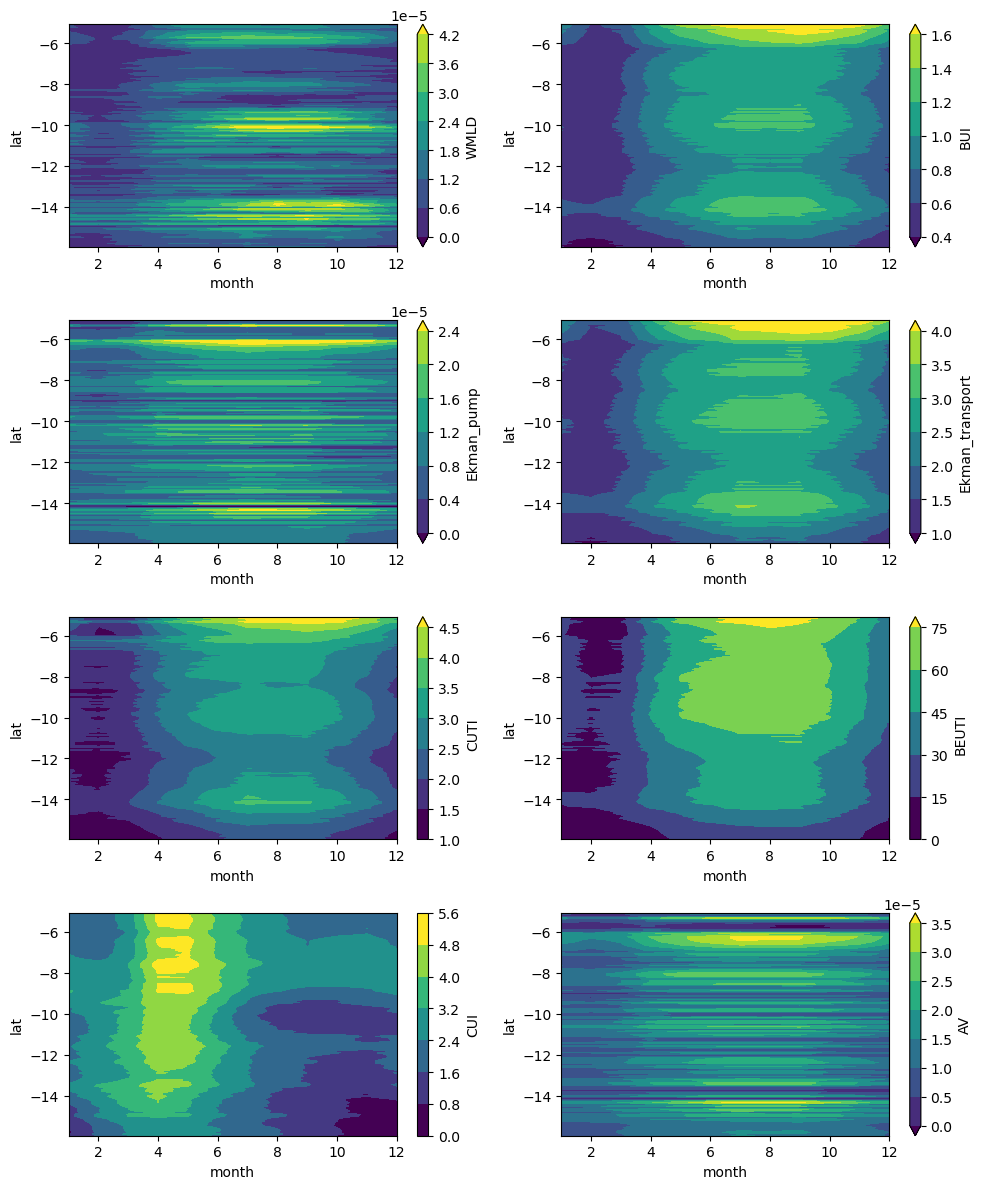

In [14]:
fig, ax = plt.subplots(4, 2, figsize=(10, 12))
# accede a cada subplot directamente

UI_season_mean.WMLD.plot.contourf(x='month', y='lat', robust=True, ax=ax[0, 0])
UI_season_mean.BUI.plot.contourf(x='month', y='lat', robust=True, ax=ax[0, 1])
UI_season_mean.Ekman_pump.plot.contourf(x='month', y='lat', robust=True, ax=ax[1, 0])
UI_season_mean.Ekman_transport.plot.contourf(x='month', y='lat', robust=True, ax=ax[1, 1])
UI_season_mean.CUTI.plot.contourf(x='month', y='lat', robust=True, ax=ax[2, 0])
UI_season_mean.BEUTI.plot.contourf(x='month', y='lat', robust=True, ax=ax[2, 1])
UI_season_mean.CUI.plot.contourf(x='month', y='lat', robust=True, ax=ax[3, 0])
UI_season_mean.AV.rename('AV').plot.contourf(x='month', y='lat', robust=True, ax=ax[3, 1])
# Elimina el subplot vacío (posición 4,1)
# fig.delaxes(ax[3, 1])

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Seasonal Upwelling')

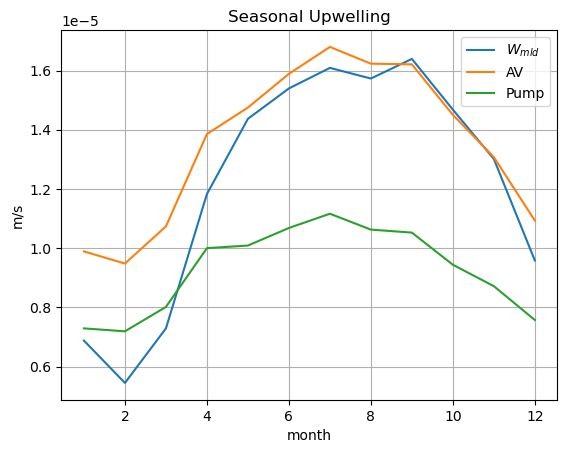

In [15]:
UI_season_mean.WMLD.mean(dim='lat',skipna=True).plot(label='$W_{mld}$')
UI_season_mean.AV.rename('AV').mean(dim='lat',skipna=True).plot(label='AV')
UI_season_mean.Ekman_pump.rename('m/s').mean(dim='lat',skipna=True).plot(label='Pump')
plt.legend()
plt.grid()
plt.title('Seasonal Upwelling')

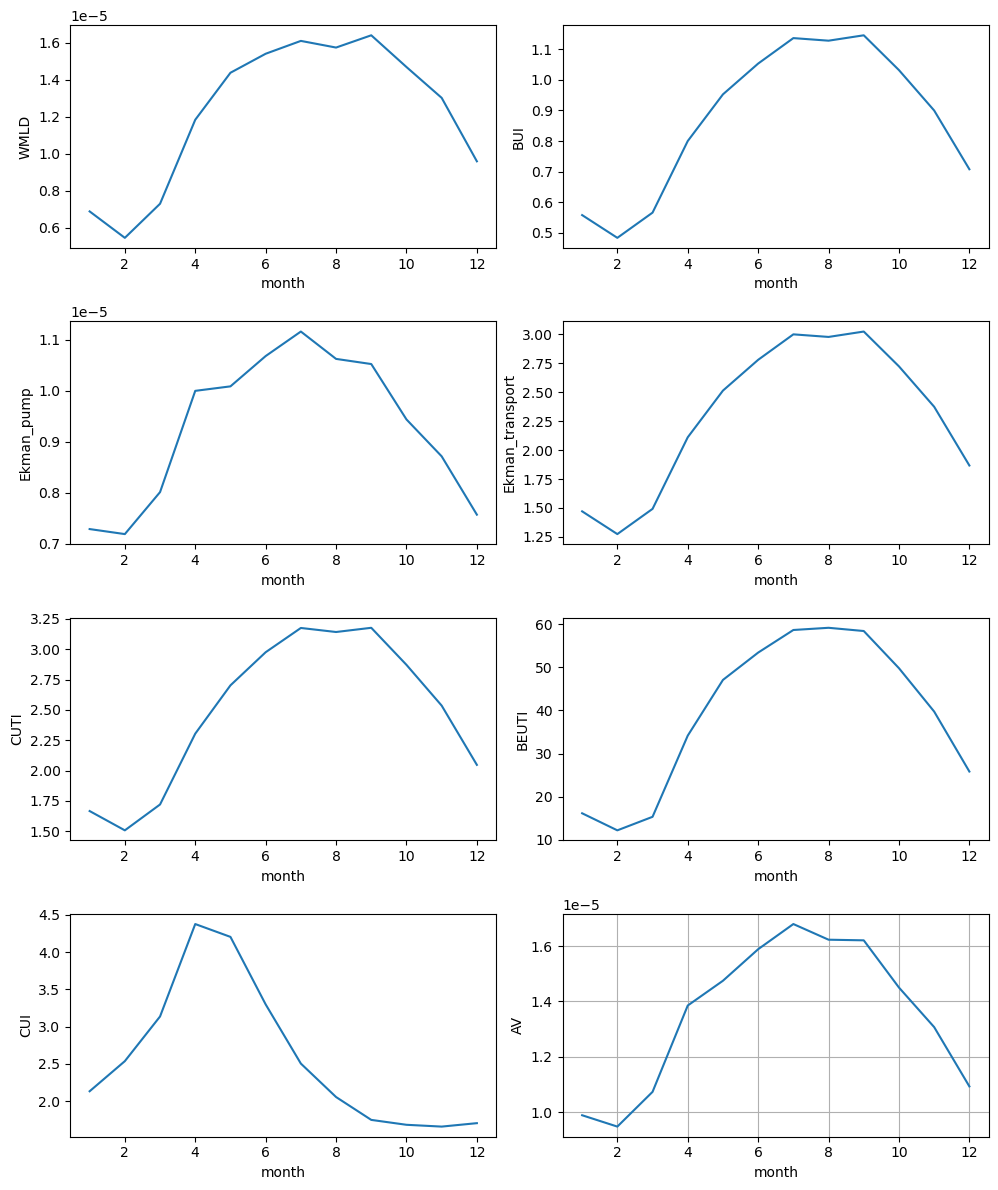

In [16]:
fig, ax = plt.subplots(4, 2, figsize=(10, 12))
# accede a cada subplot directamente

UI_season_mean.WMLD.mean(dim='lat',skipna=True).plot(x='month', ax=ax[0, 0])
UI_season_mean.BUI.mean(dim='lat',skipna=True).plot(x='month', ax=ax[0, 1])
UI_season_mean.Ekman_pump.mean(dim='lat',skipna=True).plot(x='month', ax=ax[1, 0])
UI_season_mean.Ekman_transport.mean(dim='lat',skipna=True).plot(x='month', ax=ax[1, 1])
UI_season_mean.CUTI.mean(dim='lat',skipna=True).plot(x='month', ax=ax[2, 0])
UI_season_mean.BEUTI.mean(dim='lat',skipna=True).plot(x='month', ax=ax[2, 1])
UI_season_mean.CUI.mean(dim='lat',skipna=True).plot(x='month', ax=ax[3, 0])
UI_season_mean.AV.rename('AV').mean(dim='lat',skipna=True).plot(x='month', ax=ax[3, 1])

# Elimina el subplot vacío (posición 4,1)
# fig.delaxes(ax[3, 1])

plt.tight_layout()
plt.grid()
plt.show()

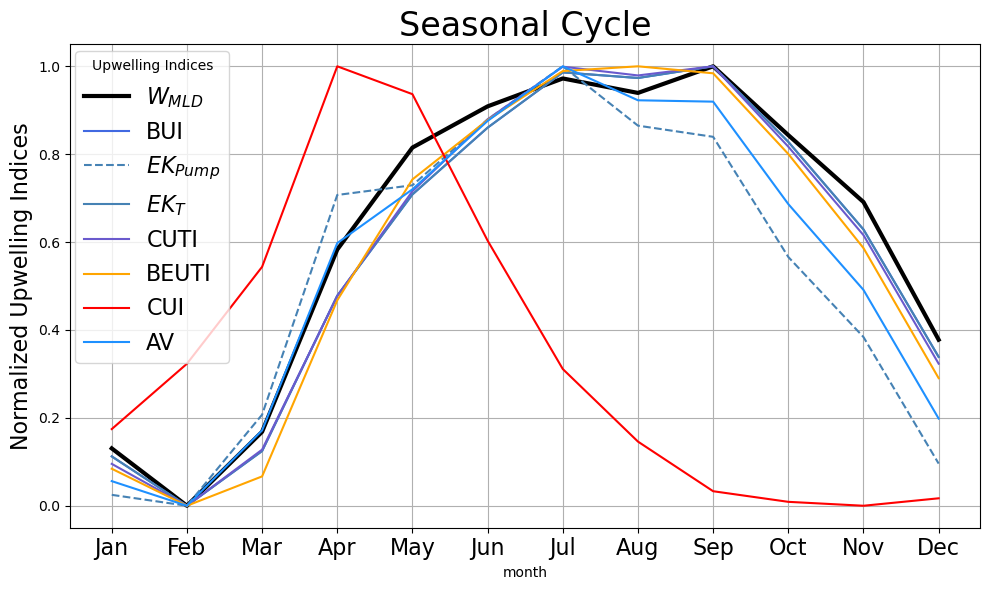

In [17]:
plt.figure(figsize=(10, 6))

normalize(UI_season_mean.WMLD.mean(dim='lat',skipna=True)).plot(color='black',linewidth=3,label='$W_{MLD}$')
normalize(UI_season_mean.BUI.mean(dim='lat',skipna=True)).plot(color='royalblue',label='BUI')
normalize(UI_season_mean.Ekman_pump.mean(dim='lat',skipna=True)).plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
normalize(UI_season_mean.Ekman_transport.mean(dim='lat',skipna=True)).plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
normalize(UI_season_mean.CUTI.mean(dim='lat',skipna=True)).plot(color='slateblue',label='CUTI')
normalize(UI_season_mean.BEUTI.mean(dim='lat',skipna=True)).plot(color='orange',label='BEUTI')
normalize(UI_season_mean.CUI.mean(dim='lat',skipna=True)).plot(color='red',label='CUI')
normalize(UI_season_mean.AV.rename('AV').mean(dim='lat',skipna=True)).plot(color='dodgerblue',label='AV')

plt.ylabel('Normalized Upwelling Indices',fontsize=16)
plt.title('Seasonal Cycle',fontsize=24)
plt.grid(True)
plt.legend()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

plt.legend(
    title='Upwelling Indices',
    loc='upper center',       # Position at top-center
    bbox_to_anchor=(0.09, 1.01
                   ),  # Center horizontally (x=0.5), just below top (y=1)
    ncol=1,  # Number of columns = number of legend items
    frameon=True,           # Remove legend border (optional)
    fontsize=16            # Adjust font size
)

plt.tight_layout()  # Prevent label clipping
# plt.savefig('Figures/Seasonal_cycle_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

plt.show()

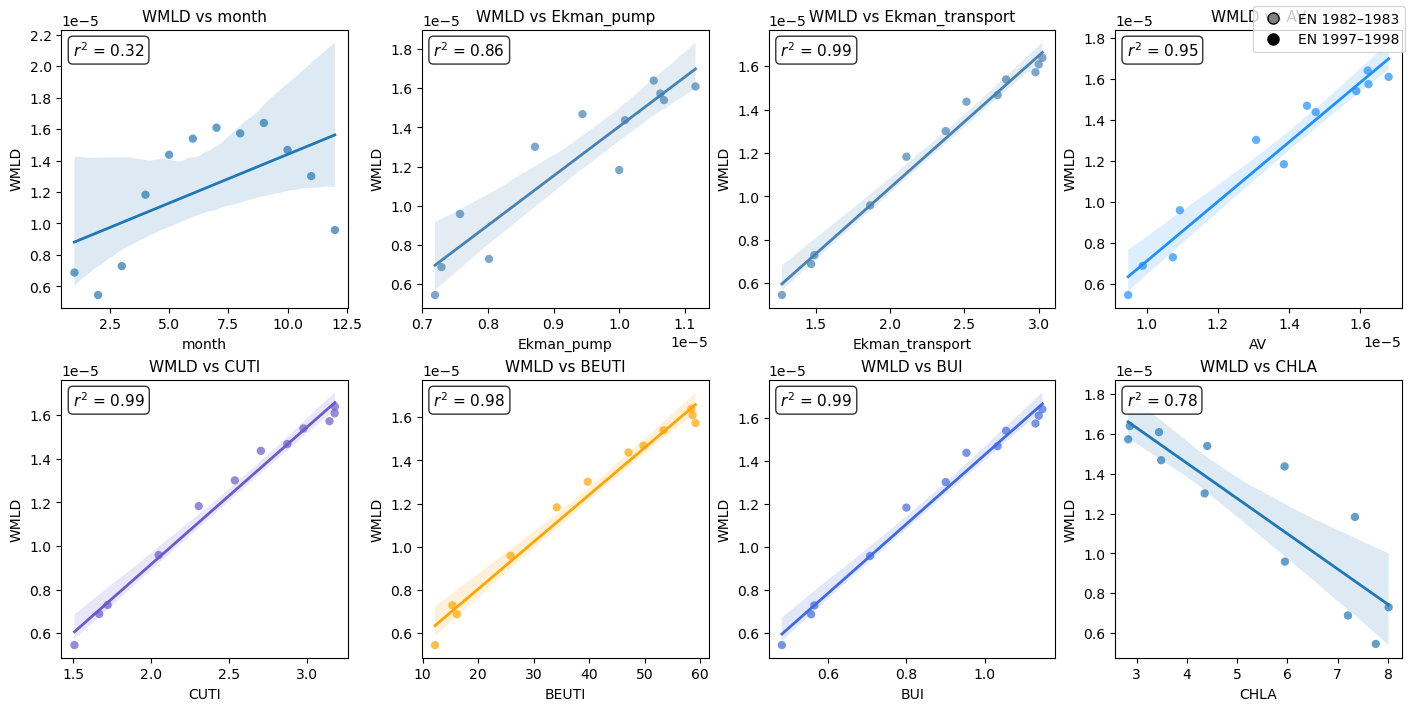

In [18]:
plot_WMLD_scatter_matrix(UI_season_mean.mean('lat'), y_var='WMLD')
plt.show()

## Interannual Variability

In [19]:
UI_ts = UI_ds.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5))
UI_ts['CUI'] = CUI_ds.sel(lat=slice(-16,-5))
UI_ts

<xarray.Dataset> Size: 4MB
Dimensions:          (time: 432, lat: 134)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * lat              (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
Data variables:
    WMLD             (time, lat) float64 463kB 3.846e-06 3.893e-06 ... 5.546e-06
    Ekman_pump       (time, lat) float64 463kB 5.013e-06 5.36e-06 ... 6.537e-06
    Ekman_transport  (time, lat) float64 463kB 1.039 0.9855 ... 4.725 4.869
    AV               (time, lat) float64 463kB 7.759e-06 7.874e-06 ... 1.259e-05
    CUTI             (time, lat) float64 463kB 1.172 1.208 1.173 ... 4.812 4.949
    BEUTI            (time, lat) float64 463kB 4.42 5.478 5.382 ... 49.42 51.6
    BUI              (time, lat) float64 463kB 0.3939 0.3735 0.4 ... 1.791 1.845
    CHLA             (time, lat) float64 463kB 6.441 7.355 7.184 ... 5.936 6.193
    CUI              (time, lat) float32 232kB 1.252 1.419 1.36 ... 1.777 1.826

In [20]:
def monthly_anomaly(da, dim='lat'):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

In [21]:
UI_ts_anom = monthly_anomaly(UI_ts)
UI_ts_anom

<xarray.Dataset> Size: 36kB
Dimensions:          (time: 432)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
    month            (time) int64 3kB 1 2 3 4 5 6 7 8 9 ... 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (time) float64 3kB -5.063e-07 -5.294e-08 ... 3.362e-06
    Ekman_pump       (time) float64 3kB -3.261e-07 -8.216e-08 ... 4.061e-07
    Ekman_transport  (time) float64 3kB -0.1115 0.01201 ... 0.6622 0.7174
    AV               (time) float64 3kB -5.953e-07 -1.263e-07 ... 1.894e-06
    CUTI             (time) float64 3kB -0.1166 -0.00199 ... 0.7635 0.8066
    BEUTI            (time) float64 3kB -1.57 0.5556 -0.4435 ... 10.73 15.63
    BUI              (time) float64 3kB -0.04225 0.004551 ... 0.2509 0.2719
    CHLA             (time) float64 3kB 2.357 1.601 0.01797 ... -0.9339 -1.165
    CUI              (time) float32 2kB 0.5885 0.5215 0.4368 ... -0.2501 -0.2986

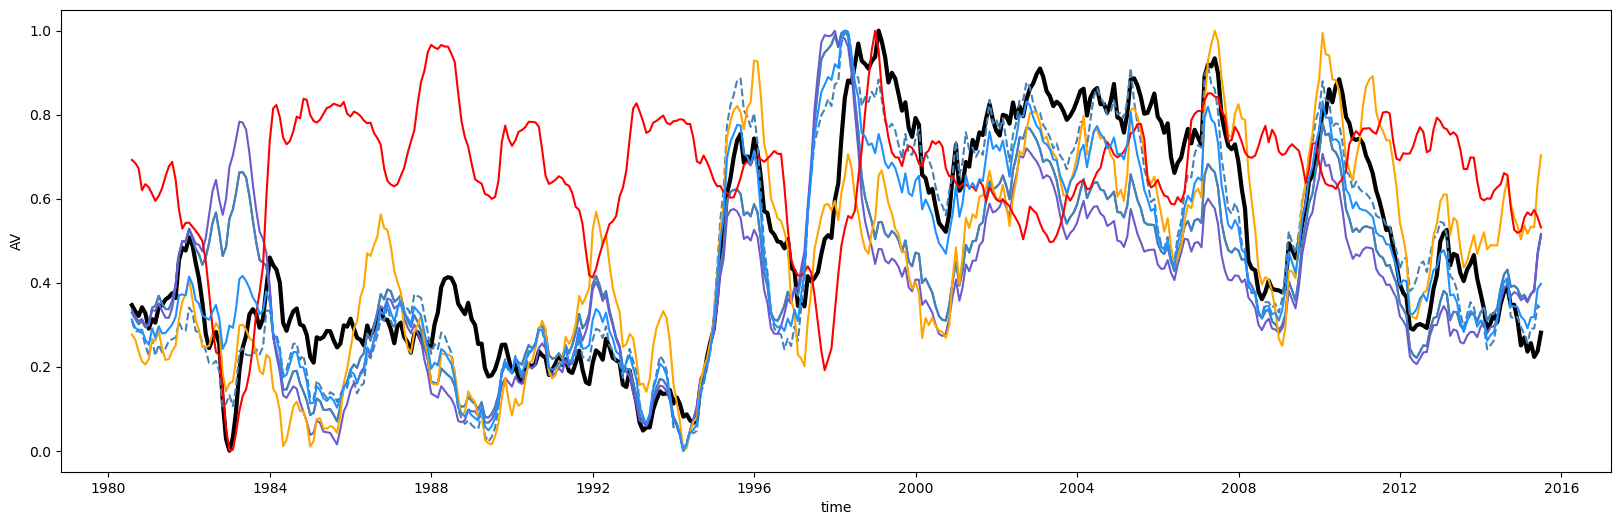

In [22]:
plt.figure(figsize=(20, 6))

normalize(UI_ts_anom.WMLD.rolling(time=13,center=True).mean()).plot(color='black',linewidth=3,label='$W_{MLD}$')
normalize(UI_ts_anom.BUI.rolling(time=13,center=True).mean()).plot(color='royalblue',label='BUI')
normalize(UI_ts_anom.Ekman_pump.rolling(time=13,center=True).mean()).plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
normalize(UI_ts_anom.Ekman_transport.rolling(time=13,center=True).mean()).plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
normalize(UI_ts_anom.CUTI.rolling(time=13,center=True).mean()).plot(color='slateblue',label='CUTI')
normalize(UI_ts_anom.BEUTI.rolling(time=13,center=True).mean()).plot(color='orange',label='BEUTI')
normalize(UI_ts_anom.CUI.rolling(time=13,center=True).mean()).plot(color='red',label='CUI')
normalize(UI_ts_anom.AV.rolling(time=13,center=True).mean()).plot(color='dodgerblue',label='AV')


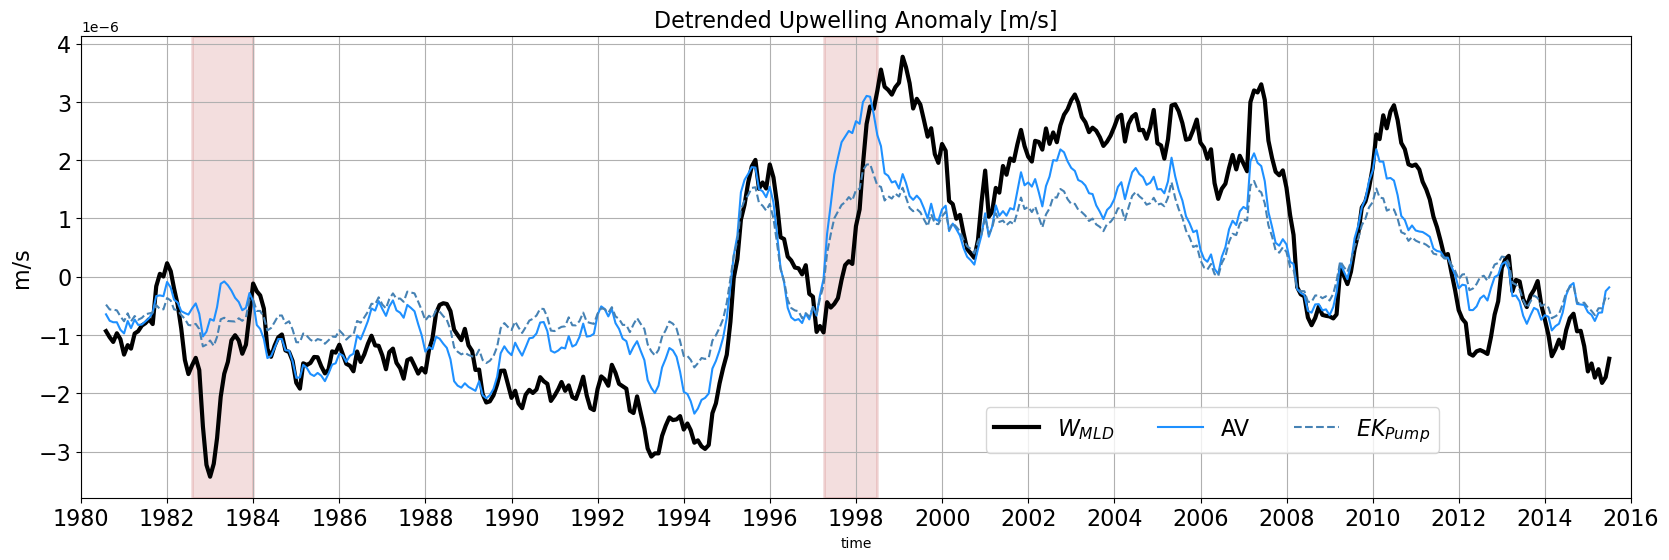

In [23]:
plt.figure(figsize=(20, 6))
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle

UI_ts_anom.WMLD.rolling(time=13,center=True).mean().plot(color='black',linewidth=3,label='$W_{MLD}$')
UI_ts_anom.AV.rolling(time=13,center=True).mean().plot(color='dodgerblue',label='AV')
UI_ts_anom.Ekman_pump.rolling(time=13,center=True).mean().plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')

plt.ylabel('m/s',fontsize=16)
plt.title('Internannual Variability',fontsize=24)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.73, 0.22),
    ncol=5,
    frameon=True,
    fontsize=16
)

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')

# plt.savefig('Figures/Interannual_variability_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.title('Detrended Upwelling Anomaly [m/s]',fontsize=16)
plt.show()


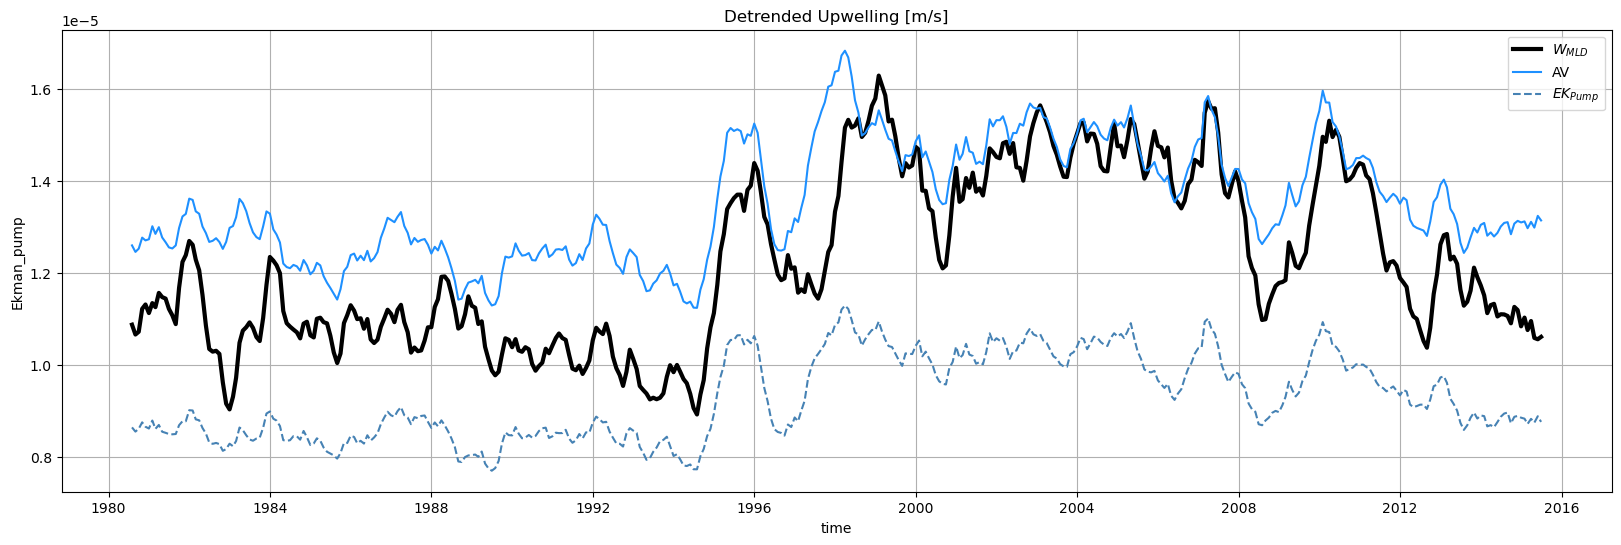

In [24]:
plt.figure(figsize=(20, 6))
UI_ts.mean('lat').WMLD.rolling(time=13,center=True).mean().plot(color='black',linewidth=3,label='$W_{MLD}$')
UI_ts.mean('lat').AV.rolling(time=13,center=True).mean().plot(color='dodgerblue',label='AV')
UI_ts.mean('lat').Ekman_pump.rolling(time=13,center=True).mean().plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
plt.grid()
plt.title('Detrended Upwelling [m/s]')
plt.legend()

/tmp/ipykernel_555280/1807575349.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  plot_WMLD_scatter_matrix(UI_ts_anom.drop('month').rolling(time=13,center=True).mean(), y_var='WMLD')


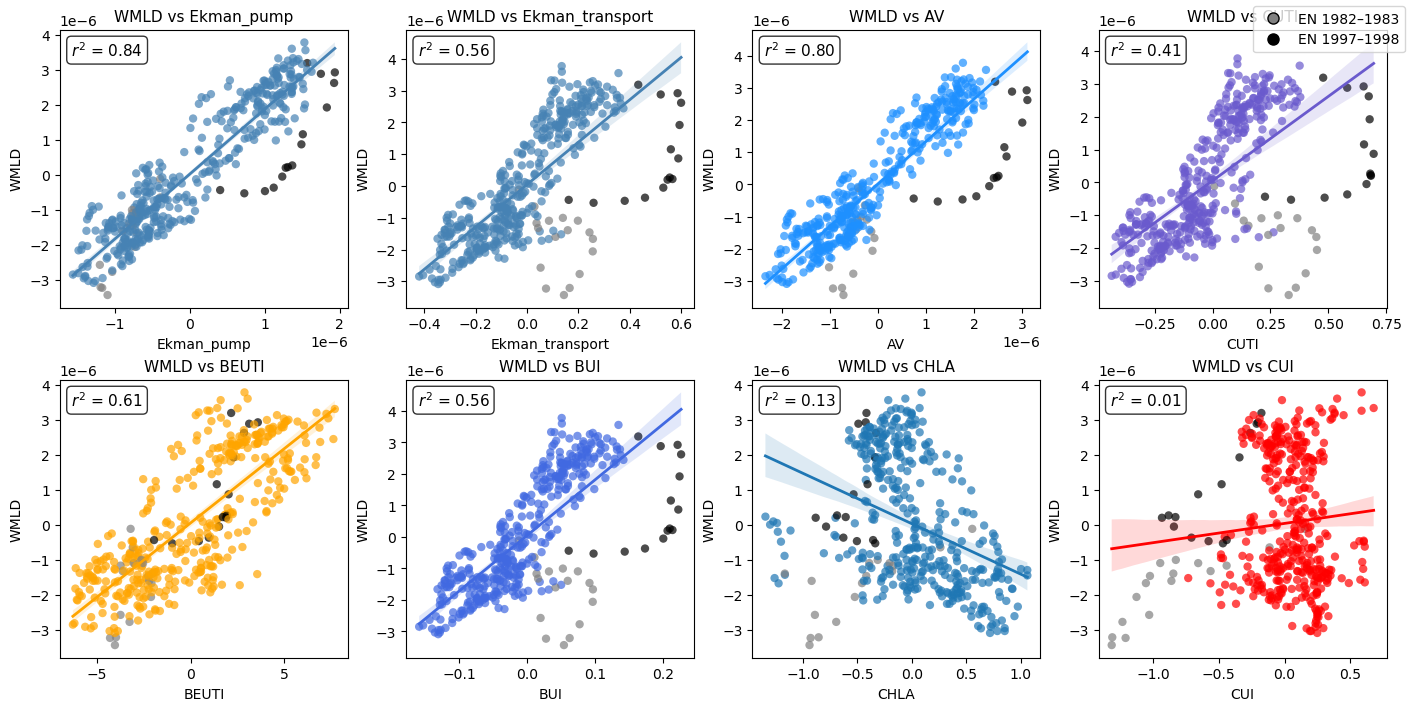

In [25]:
plot_WMLD_scatter_matrix(UI_ts_anom.drop('month').rolling(time=13,center=True).mean(), y_var='WMLD')

# plt.savefig('Figures/paper/fig4_correlations.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

/tmp/ipykernel_1239175/473500957.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  plot_WMLD_scatter_matrix(UI_ts_anom.drop('month').rolling(time=13,center=True).mean(), y_var='CHLA')


(<Figure size 1400x700 with 8 Axes>,
 array([<Axes: title={'center': 'CHLA vs WMLD'}, xlabel='WMLD', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs Ekman_pump'}, xlabel='Ekman_pump', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs Ekman_transport'}, xlabel='Ekman_transport', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs AV'}, xlabel='AV', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs CUTI'}, xlabel='CUTI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs BEUTI'}, xlabel='BEUTI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs BUI'}, xlabel='BUI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs CUI'}, xlabel='CUI', ylabel='CHLA'>],
       dtype=object))

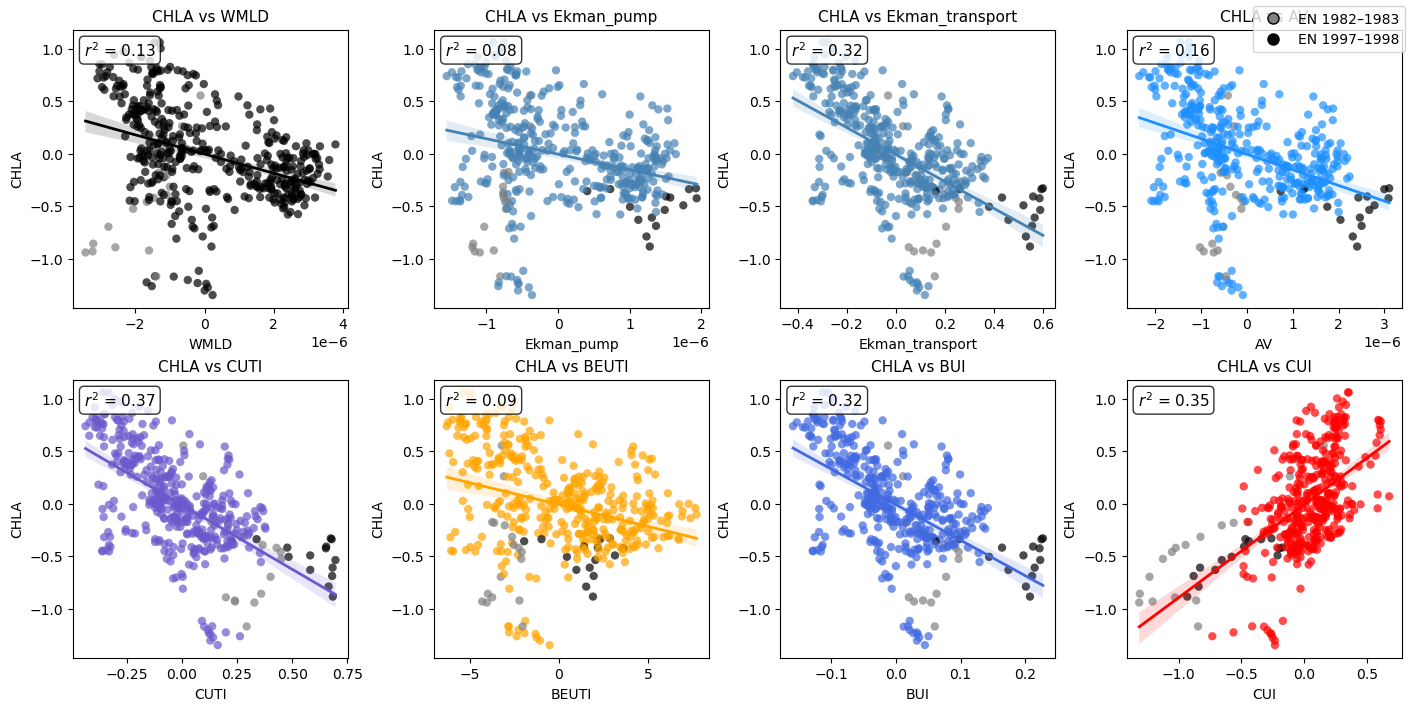

In [26]:
plot_WMLD_scatter_matrix(UI_ts_anom.drop('month').rolling(time=13,center=True).mean(), y_var='CHLA')

## Yearly

In [27]:
UI_year = UI_ts.groupby('time.year').mean(dim=('time','lat'),skipna=True)
UI_year

<xarray.Dataset> Size: 3kB
Dimensions:          (year: 36)
Coordinates:
  * year             (year) int64 288B 1980 1981 1982 1983 ... 2013 2014 2015
Data variables:
    WMLD             (year) float64 288B 1.112e-05 1.138e-05 ... 1.054e-05
    Ekman_pump       (year) float64 288B 8.761e-06 8.633e-06 ... 8.768e-06
    Ekman_transport  (year) float64 288B 2.207 2.225 2.404 ... 2.179 2.302 2.381
    AV               (year) float64 288B 1.283e-05 1.276e-05 ... 1.318e-05
    CUTI             (year) float64 288B 2.422 2.407 2.713 ... 2.337 2.477 2.615
    BEUTI            (year) float64 288B 36.52 35.97 36.46 ... 39.41 41.07 42.28
    BUI              (year) float64 288B 0.8363 0.8434 0.911 ... 0.8722 0.9024
    CHLA             (year) float64 288B 5.695 4.843 4.075 ... 5.306 5.455 5.16
    CUI              (year) float32 144B 2.644 2.635 1.937 ... 2.682 2.568 2.296

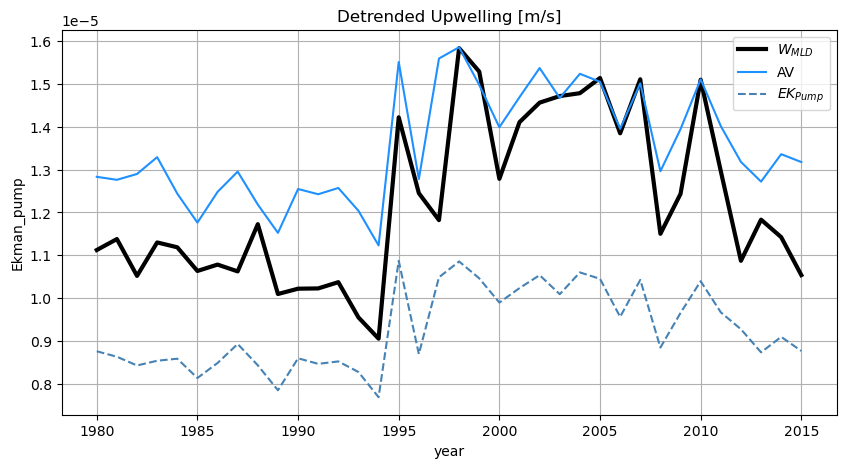

In [28]:
plt.figure(figsize=(10, 5))
UI_year.WMLD.plot(color='black',linewidth=3,label='$W_{MLD}$')
UI_year.AV.plot(color='dodgerblue',label='AV')
UI_year.Ekman_pump.plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
plt.grid()
plt.title('Detrended Upwelling [m/s]')
plt.legend()

In [29]:
df = UI_year.to_dataframe().reset_index()
df = df.drop(df.columns[0], axis=1)
df.head()

,WMLD,Ekman_pump,Ekman_transport,AV,CUTI,BEUTI,BUI,CHLA,CUI
0,0.000011,0.000009,2.206801,0.000013,2.421942,36.524900,0.836312,5.695037,2.643586
1,0.000011,0.000009,2.225493,0.000013,2.406999,35.971251,0.843395,4.842560,2.635332
2,0.000011,0.000008,2.403912,0.000013,2.713264,36.464849,0.911011,4.074707,1.936943
3,0.000011,0.000009,2.484465,0.000013,2.824470,36.853038,0.941538,4.933077,1.685362
4,0.000011,0.000009,2.073256,0.000012,2.226753,34.166402,0.785702,5.574731,2.748799


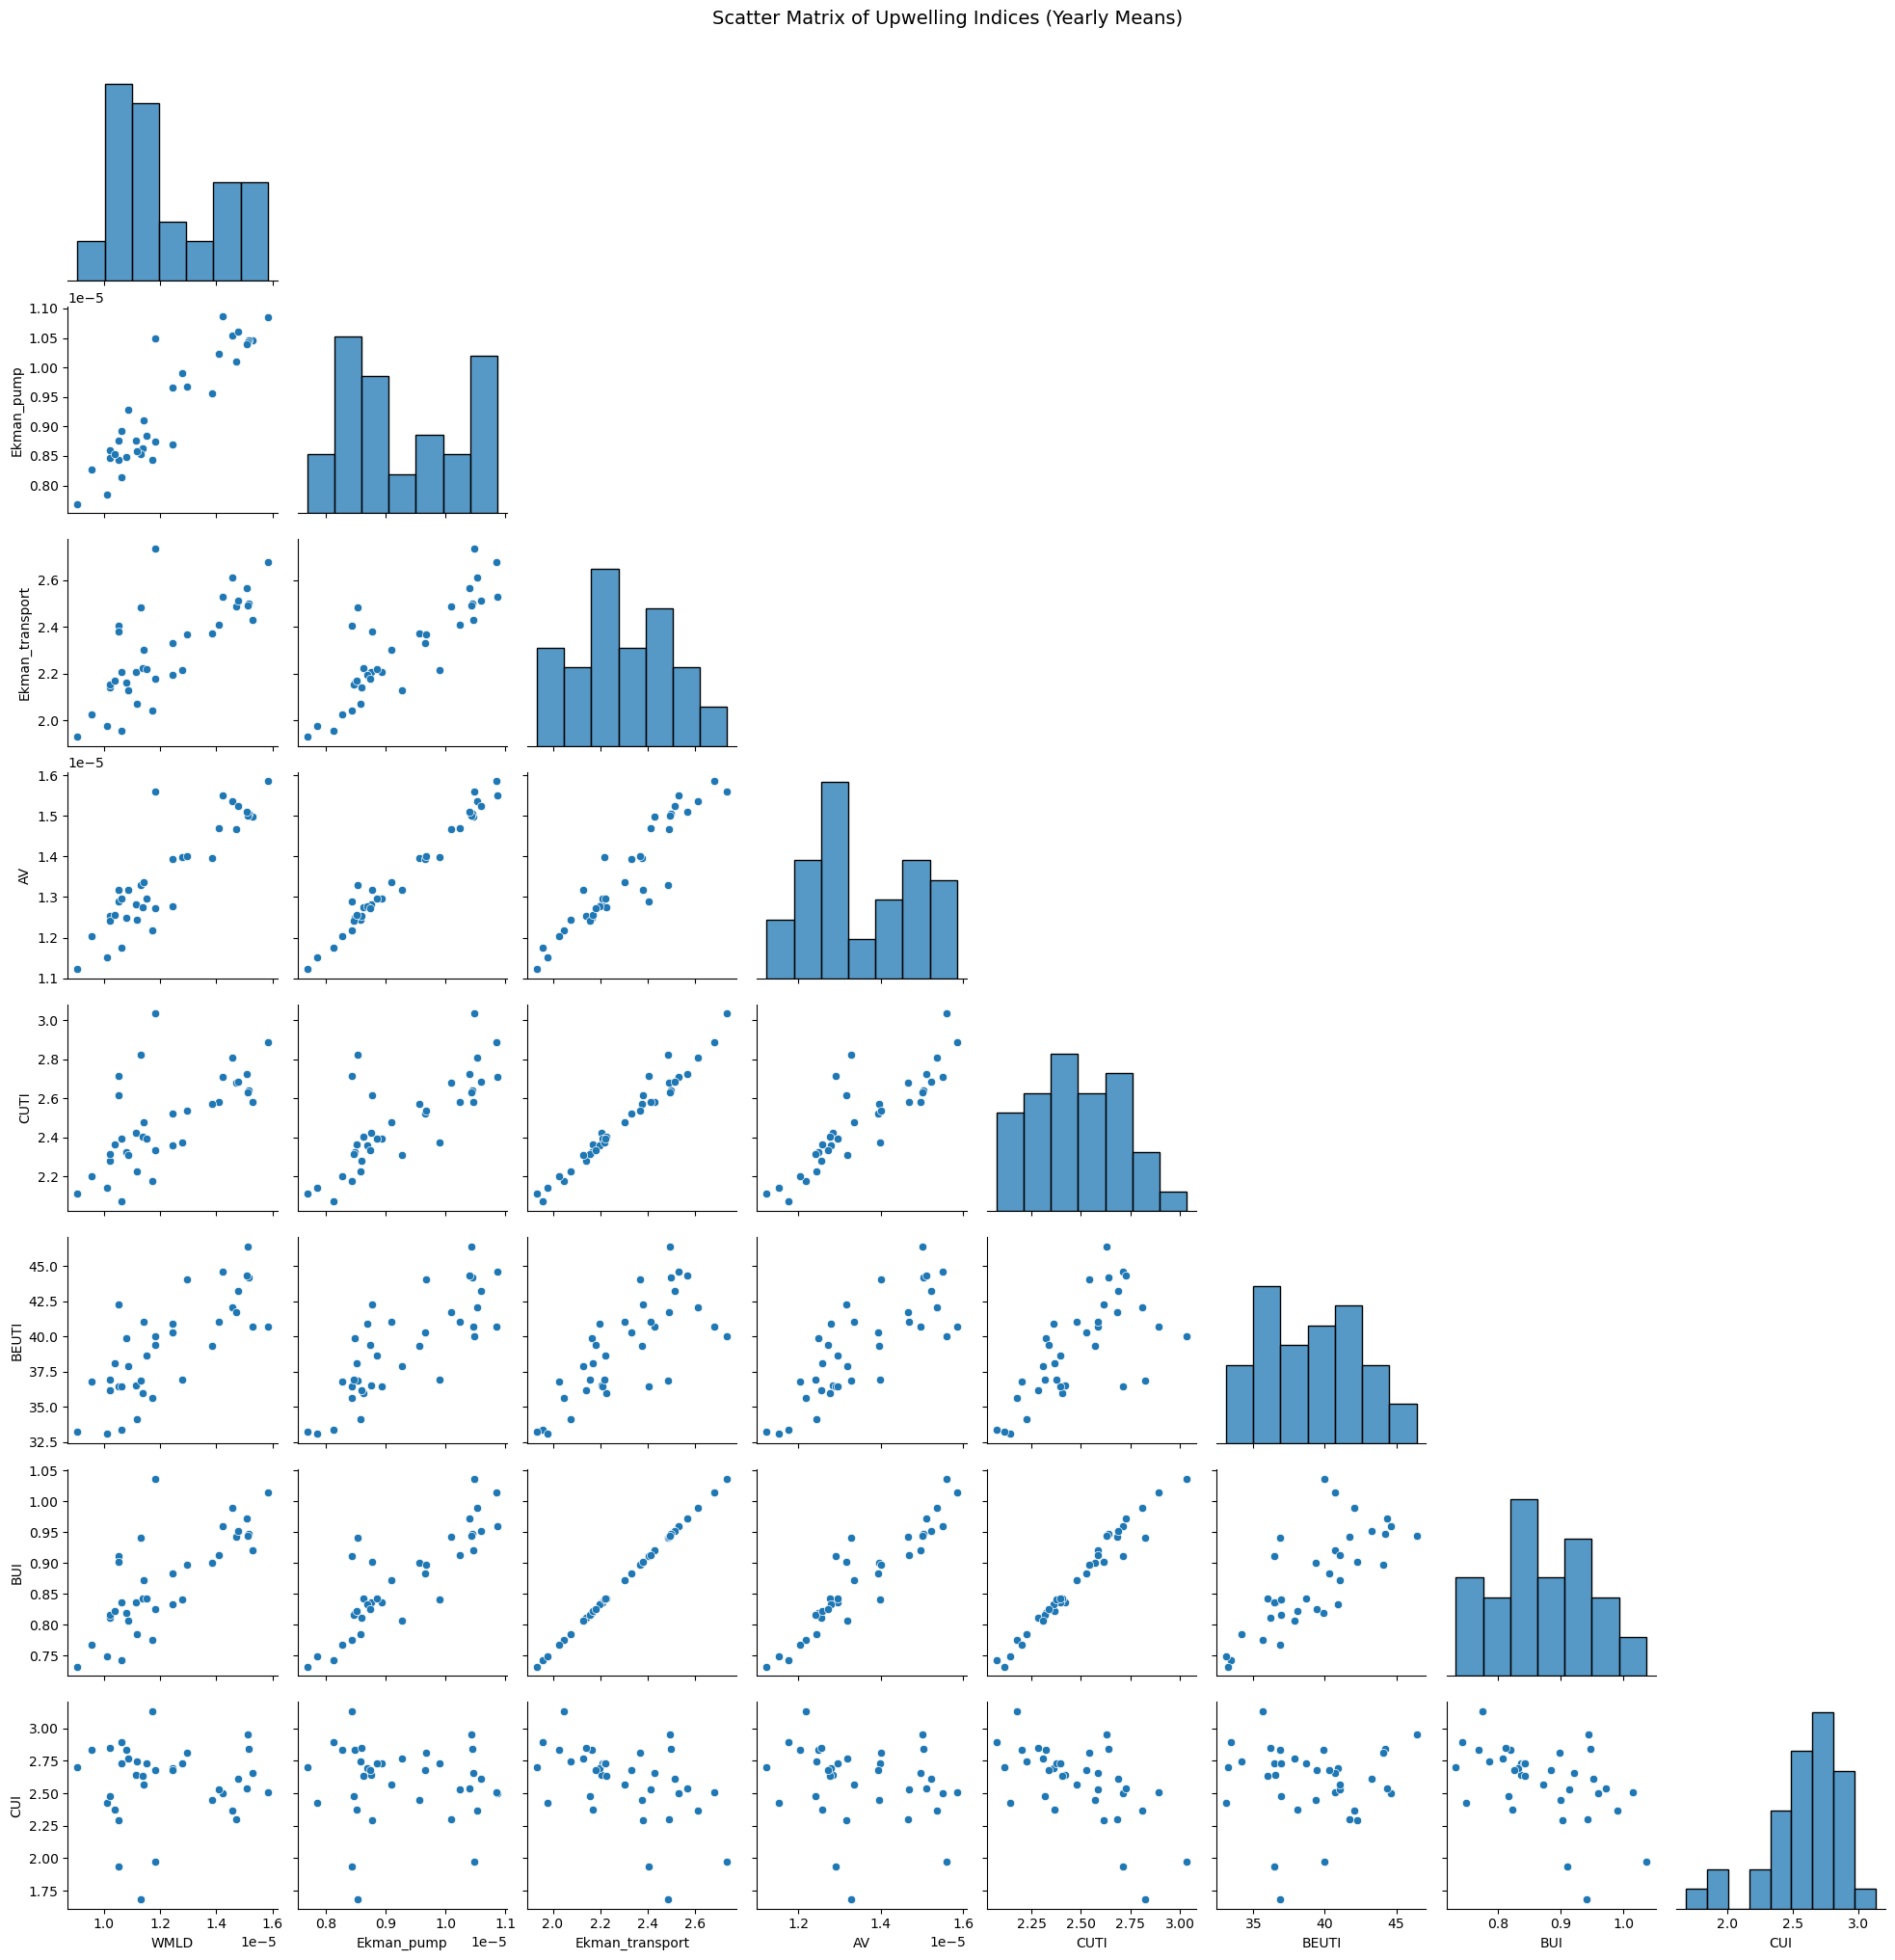

In [30]:
import seaborn as sns
# import matplotlib.pyplot as plt

# Optional: choose only the variable columns
vars_to_plot = ['WMLD', 'Ekman_pump', 'Ekman_transport', 'AV', 'CUTI', 'BEUTI', 'BUI', 'CUI']
sns.pairplot(df[vars_to_plot], corner=True)

plt.suptitle("Scatter Matrix of Upwelling Indices (Yearly Means)", fontsize=14, y=1.02)
plt.show()

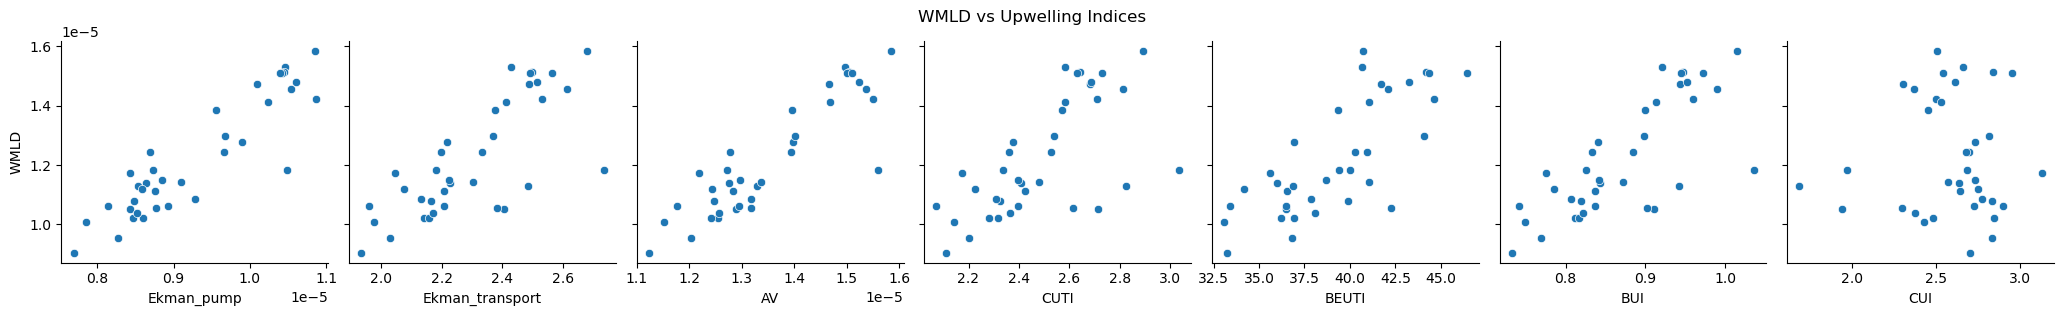

In [31]:
# Set WMLD vs all others
sns.pairplot(df, x_vars=['Ekman_pump', 'Ekman_transport', 'AV', 'CUTI', 'BEUTI', 'BUI', 'CUI'],
                  y_vars='WMLD',
                  height=3, aspect=1)

plt.suptitle("WMLD vs Upwelling Indices", y=1.02)
plt.show()

(<Figure size 1400x700 with 8 Axes>,
 array([<Axes: title={'center': 'WMLD vs Ekman_pump'}, xlabel='Ekman_pump', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs Ekman_transport'}, xlabel='Ekman_transport', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs AV'}, xlabel='AV', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs CUTI'}, xlabel='CUTI', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs BEUTI'}, xlabel='BEUTI', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs BUI'}, xlabel='BUI', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs CHLA'}, xlabel='CHLA', ylabel='WMLD'>,
        <Axes: title={'center': 'WMLD vs CUI'}, xlabel='CUI', ylabel='WMLD'>],
       dtype=object))

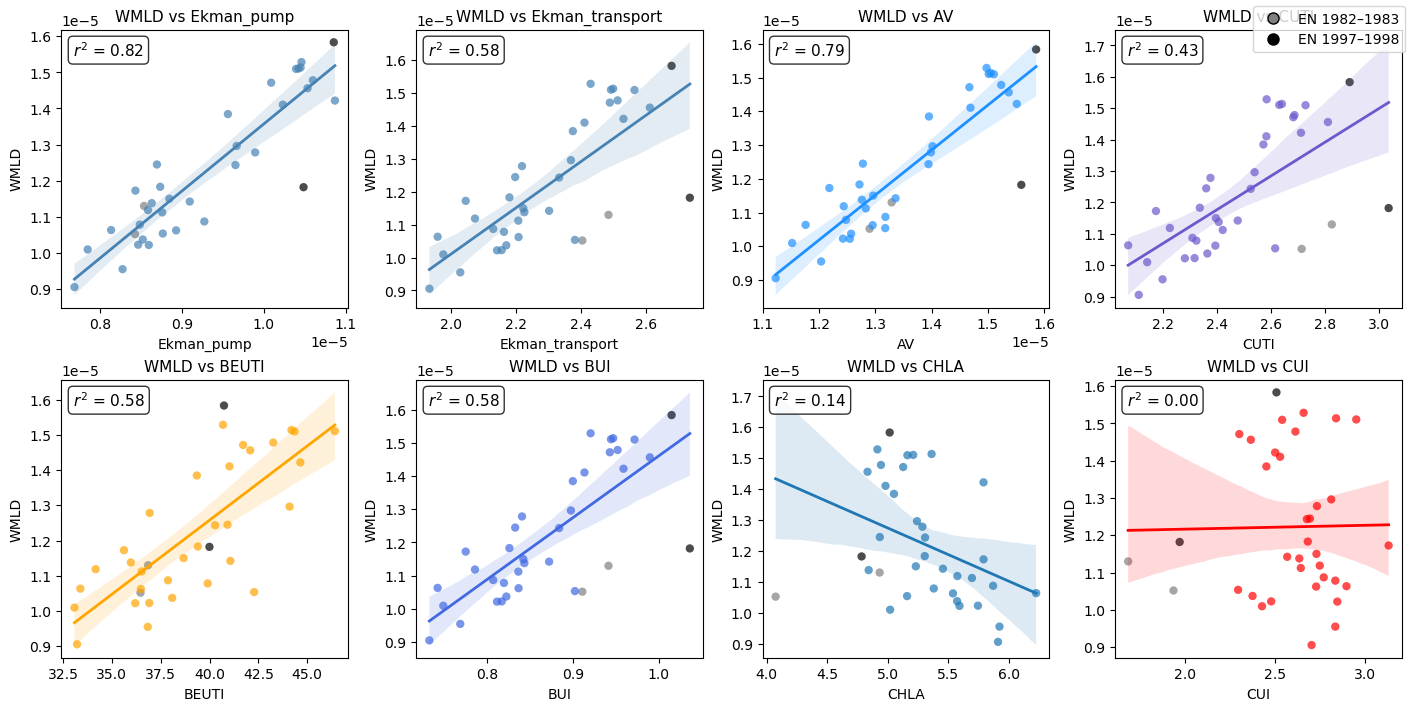

In [35]:
plot_WMLD_scatter_matrix(UI_year, y_var='WMLD')

(<Figure size 1400x700 with 8 Axes>,
 array([<Axes: title={'center': 'CHLA vs WMLD'}, xlabel='WMLD', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs Ekman_pump'}, xlabel='Ekman_pump', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs Ekman_transport'}, xlabel='Ekman_transport', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs AV'}, xlabel='AV', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs CUTI'}, xlabel='CUTI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs BEUTI'}, xlabel='BEUTI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs BUI'}, xlabel='BUI', ylabel='CHLA'>,
        <Axes: title={'center': 'CHLA vs CUI'}, xlabel='CUI', ylabel='CHLA'>],
       dtype=object))

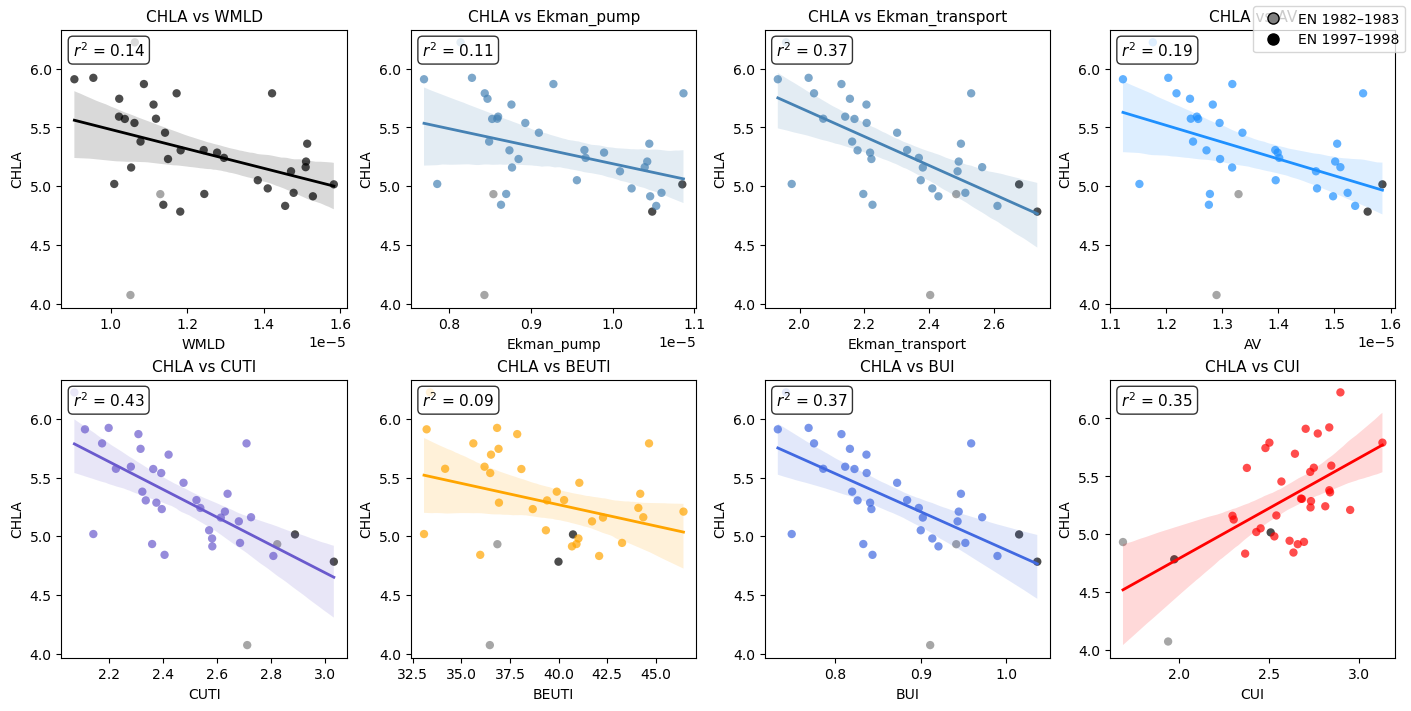

In [37]:
plot_WMLD_scatter_matrix(UI_year, y_var='CHLA')

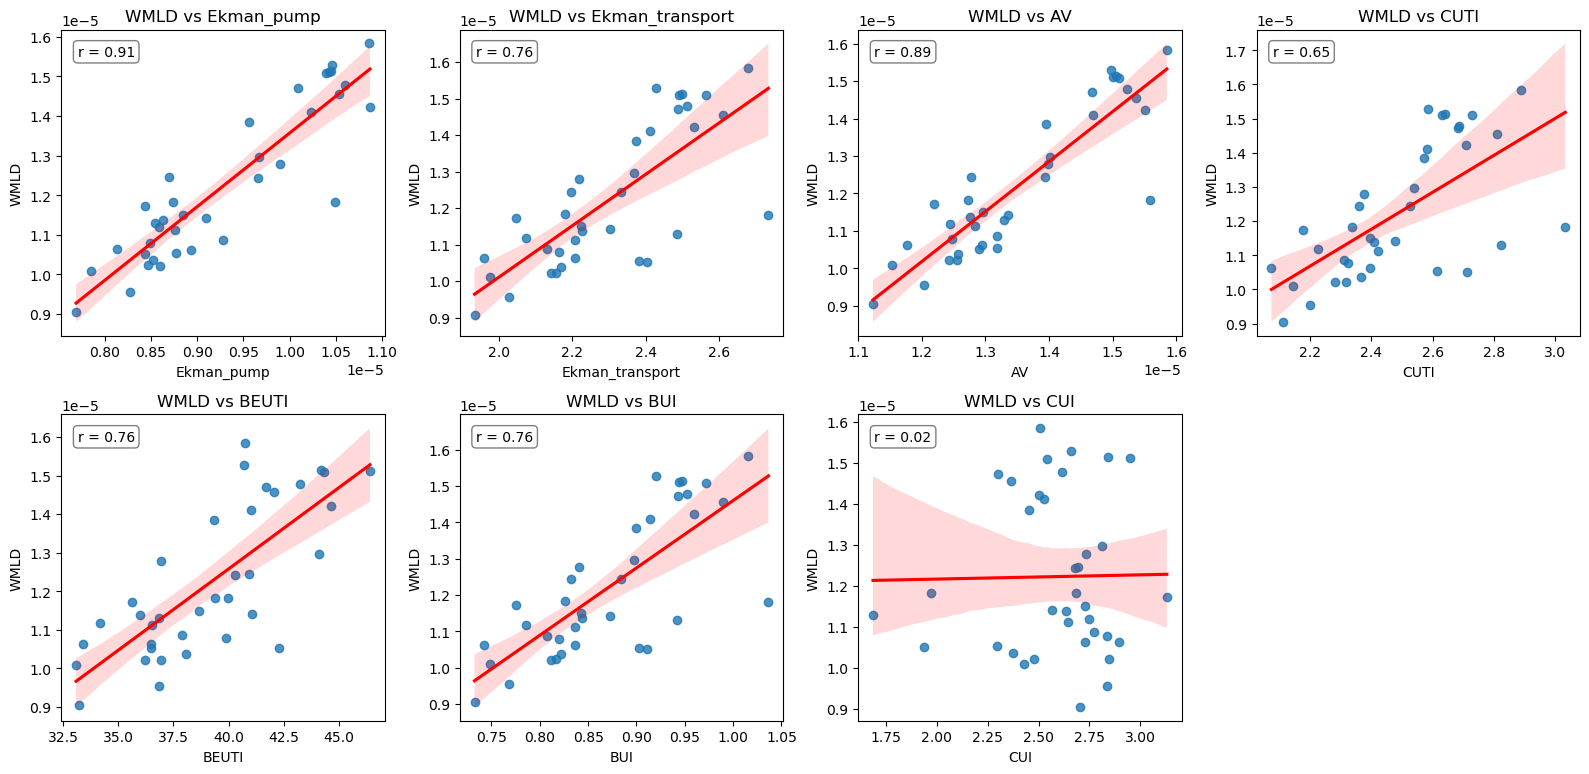

In [33]:
from scipy.stats import pearsonr

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()

vars_to_plot = ['Ekman_pump', 'Ekman_transport', 'AV', 'CUTI', 'BEUTI', 'BUI', 'CUI']

for i, var in enumerate(vars_to_plot):
    x = df[var]
    y = df['WMLD']

    # Plot with regression and 95% confidence interval
    sns.regplot(x=x, y=y, ax=axs[i], ci=95, line_kws={'color': 'red'})

    # Calculate Pearson r
    r, p = pearsonr(x, y)
    r_text = f"r = {r:.2f}"
    
    # Annotate inside plot
    axs[i].text(0.05, 0.95, r_text, transform=axs[i].transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

    axs[i].set_xlabel(var)
    axs[i].set_ylabel('WMLD')
    axs[i].set_title(f'WMLD vs {var}')

# Hide last unused subplot
axs[-1].axis('off')

plt.tight_layout()
plt.show()


### Spatial Variability

/tmp/ipykernel_1239175/561245609.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


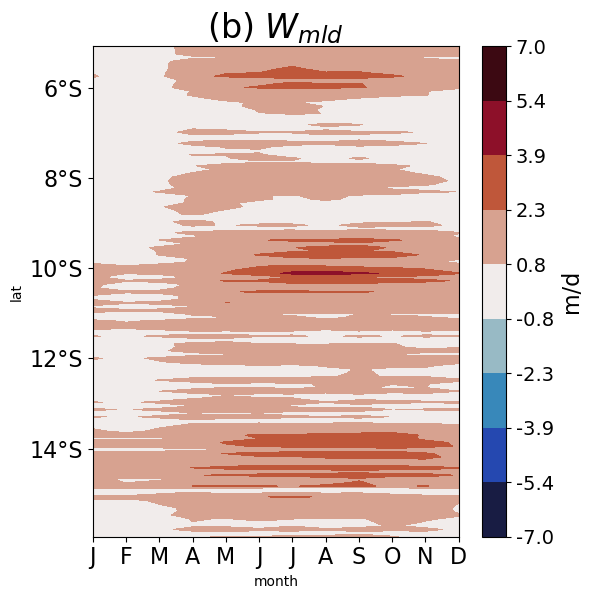

In [34]:
fig, ax = plt.subplots(figsize=(6,6))

vmin=-7; vmax=7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf=(UI_season_mean.WMLD*86400).plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = cm.balance,
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('m/d',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(b) $W_{mld}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

# plt.savefig('Figures/wmld_season_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()